In [1]:
import pyecap
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
import pandas as pd
from tdt import read_block

In [4]:
path = r'D:\Data\TDT_fNIRs\20240315_NeuraWorx\20240315_NeuraWorx\\'
file = r'\KAL-240315-105510'

filePATH = path + file

In [5]:
raw_ecg = pyecap.Ephys(filePATH, stores='ECGG')
raw_ecg = raw_ecg.remove_ch(channels=['ECGG 3', 'ECGG 4'])
raw_TCD = pyecap.Ephys(filePATH, stores='TCDD')

time = raw_ecg.time()

stim = pyecap.Stim(filePATH)
stimDF = stim.parameters

TCD = pyecap.EMG(raw_TCD,stim)

In [6]:
stimDF

onset time (s)  offset time (s)  period (ms)  frequency (Hz)  \
0 0        35.269222        65.251939     9.994239      100.057645   
  1       162.269553       188.074351     0.286720     3487.723484   
  2       263.428588       289.233386     0.286720     3487.723484   
  3       354.690826       384.673543     9.994239      100.057645   
  4       485.137859       515.120575     9.994239      100.057645   
...              ...              ...          ...             ...   
  75     3687.840236      3713.645034     0.286720     3487.723484   
  76     3799.047250      3824.852048     0.286720     3487.723484   
  77     3891.537510      3921.520227     9.994239      100.057645   
  78     4000.184402      4030.167118     9.994239      100.057645   
  79     4093.372088      4119.176886     0.286720     3487.723484   

      pulse count  pulse amplitude (μA)  duration (ms)  pulse duration (ms)  \
0 0          3000               -7500.0   29982.716560                  0.2   
  1         90000               -7500.0   25804.798007                  0.2   
  2         90000               -7500.0   25804.798007                  0.2   
  3          3000               -7500.0   29982.716560                  0.2   
  4          3000               -7500.0   29982.716560                  0.2   
...           ...                   ...            ...                  ...   
  75        90000               -7500.0   25804.798007                  0.2   
  76        90000               -7500.0   25804.798007                  0.2   
  77         3000               -7500.0   29982.716560                  0.2   
  78         3000               -7500.0   29982.716560                  0.2   
  79        90000               -7500.0   25804.798007                  0.2   

      delay (ms)  channel voice store  
0 0          0.0        1     A  eS1p  
  1          0.0        1     A  eS1p  
  2          0.0        1     A  eS1p  
  3          0.0        1     A  eS1p  
  4          0.0        1     A  eS1p  
...          ...      ...   ...   ...  
  75         0.0        1     A  eS2p  
  76         0.0        1     A  eS2p  
  77         0.0        1     A  eS2p  
  78         0.0        1     A  eS2p  
  79         0.0        1     A  eS2p  

[80 rows x 12 columns]

In [7]:
params = stimDF.loc[(stimDF['pulse count'] == 90000) & (stimDF['store'] == 'eS1p')].index
params

MultiIndex([(0,  1),
            (0,  2),
            (0,  6),
            (0,  8),
            (0,  9),
            (0, 10),
            (0, 11),
            (0, 12),
            (0, 13),
            (0, 14),
            (0, 18),
            (0, 20),
            (0, 23),
            (0, 24),
            (0, 25),
            (0, 30),
            (0, 31),
            (0, 35),
            (0, 36),
            (0, 39)],
           )

In [8]:
TCD = raw_TCD.array[0,:]
TCD_vel = TCD * 100 #units = cm/s
time_s = np.arange(len(TCD)) / raw_TCD.sample_rate
time_m = time_s / 60

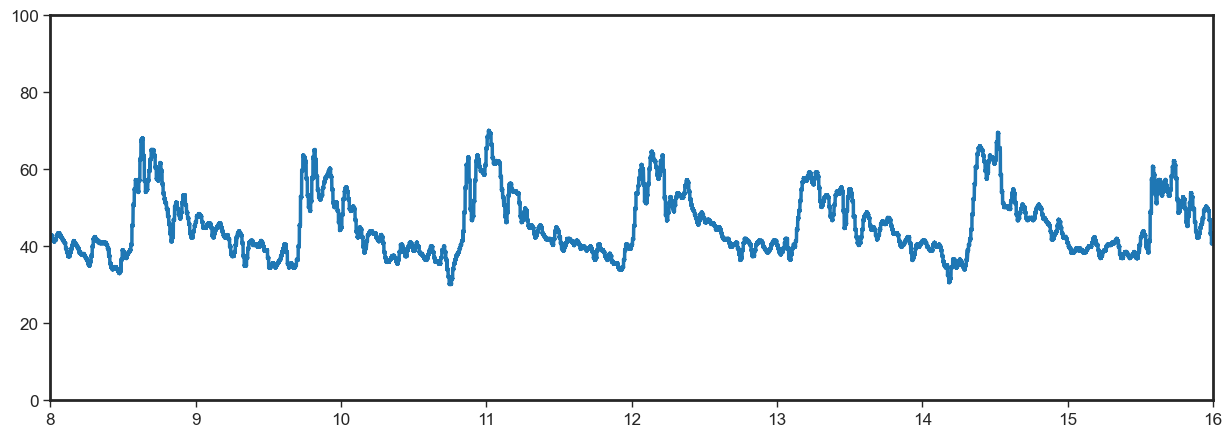

In [13]:
fig,ax = plt.subplots(figsize=(15,5))
ax.plot(time_s, TCD_vel)
ax.set_xlim(8,16)
ax.set_ylim(-0,100)
plt.show()

In [ ]:
fig,ax = plt.subplots(figsize=(20,20))

stim_on = 1260
stim_off = 1260
    
plot_start_idx = int((stim_on - 15) * raw_TCD.sample_rate)
plot_stop_idx = int((stim_off + 15) * raw_TCD.sample_rate)
    
ax.plot(time_s[plot_start_idx:plot_stop_idx],TCD_vel[plot_start_idx:plot_stop_idx])
ax.set_ylim(0,100)

plt.show()

In [ ]:
#for idx in stimDF.index[0:20]:
params = stimDF.loc[(stimDF['pulse count'] == 1200) & (stimDF['store'] == 'eS1p')].index
params

for idx in params:
    stim_idx_pairs.append([stimDF['onset time (s)'][idx], stimDF['offset time (s)'][idx]])
    
    stim_on = stimDF['onset time (s)'][idx]
    stim_off = stimDF['offset time (s)'][idx]
    
    plot_start_idx = int((stim_on - 15) * raw_TCD.sample_rate)
    plot_stop_idx = int((stim_off + 15) * raw_TCD.sample_rate)

    fig,ax = plt.subplots()
    ax.plot(time_s[plot_start_idx:plot_stop_idx],TCD_vel[plot_start_idx:plot_stop_idx])
    ax.set_ylim(0,100)
    ax.axvspan(stim_on,stim_off,alpha = 0.33, color='r')
    ax.set(title='V1 @ 100 Hz' + str(stimDF['pulse amplitude (μA)'][idx]) + ' (uA) ' + str(idx), xlabel='Time (s)', ylabel='Velocity (cm/s)')
plt.show()

In [ ]:
numcols = 2
numrows = int(len(params) / numcols)
fig,ax = plt.subplots(ncols=numcols,nrows=numrows, figsize=(15,30))
ax = ax.ravel()

for idx,param in enumerate(params):    
    stim_on = stimDF['onset time (s)'][param]
    stim_off = stimDF['offset time (s)'][param]
    
    plot_start_idx = int((stim_on - 15) * raw_TCD.sample_rate)
    plot_stop_idx = int((stim_off + 15) * raw_TCD.sample_rate)

    ax[idx].plot(time_s[plot_start_idx:plot_stop_idx],TCD_vel[plot_start_idx:plot_stop_idx])
    ax[idx].set_ylim(0,100)
    ax[idx].axvspan(stim_on,stim_off,alpha = 0.33, color='r')
    ax[idx].set(xlabel='Time (s)', ylabel='Velocity (cm/s)')
    fig.suptitle('V1 @ 3 kHz' + str(stimDF['pulse amplitude (μA)'][param]) + ' (uA) ' + str(param))
    fig.tight_layout()
plt.show()